# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-08 13:53:59,635] A new study created in memory with name: no-name-5f7cb8f2-a3e6-4f9a-90c8-ddfb56733470
[I 2026-04-08 13:53:59,716] Trial 0 finished with value: 0.7258064516129032 and parameters: {'n_estimators': 121, 'max_depth': 3}. Best is trial 0 with value: 0.7258064516129032.
[I 2026-04-08 13:53:59,887] Trial 1 finished with value: 0.732824427480916 and parameters: {'n_estimators': 205, 'max_depth': 12}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,070] Trial 2 finished with value: 0.6942148760330579 and parameters: {'n_estimators': 222, 'max_depth': 7}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,208] Trial 3 finished with value: 0.7166666666666667 and parameters: {'n_estimators': 181, 'max_depth': 6}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,382] Trial 4 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 200, 'max_depth': 14}. Best is trial 4 with value: 0.74242424242

RF F1: 0.7368421052631579
LR F1: 0.71875
SVM F1: 0.736
KNN F1: 0.7555555555555555


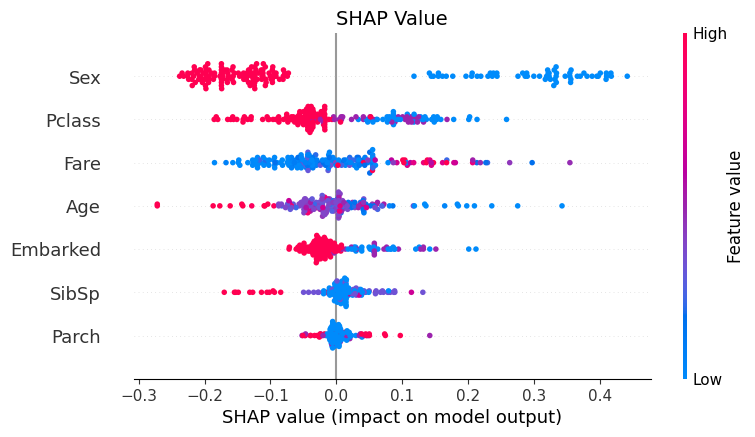

Stacking F1: 0.765625


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [ ]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])


# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=y)

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

결측치 개수 확인
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64
country mapping: {'France': 0, 'Germany': 1, 'Spain': 2}
gender mapping: {'Female': 0, 'Male': 1}


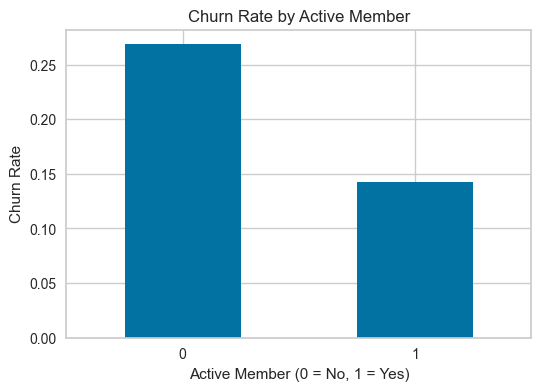

                    Description             Value
0                    Session id                42
1                        Target             churn
2                   Target type            Binary
3           Original data shape       (10000, 11)
4        Transformed data shape       (10000, 11)
5   Transformed train set shape        (8000, 11)
6    Transformed test set shape        (2000, 11)
7              Numeric features                10
8                    Preprocess              True
9               Imputation type            simple
10           Numeric imputation              mean
11       Categorical imputation              mode
12                    Normalize              True
13             Normalize method            zscore
14               Fold Generator   StratifiedKFold
15                  Fold Number                 5
16                     CPU Jobs                -1
17                      Use GPU             False
18               Log Experiment             False


                                    Model  Accuracy     AUC  Recall   Prec.  \
lightgbm  Light Gradient Boosting Machine    0.8605  0.8591  0.4847  0.7425   
catboost              CatBoost Classifier    0.8600  0.8644  0.4730  0.7475   
rf               Random Forest Classifier    0.8622  0.8533  0.4552  0.7775   
gbc          Gradient Boosting Classifier    0.8614  0.8611  0.4534  0.7739   
xgboost         Extreme Gradient Boosting    0.8526  0.8447  0.4761  0.7052   
ada                  Ada Boost Classifier    0.8508  0.8427  0.4620  0.7061   
et                 Extra Trees Classifier    0.8532  0.8461  0.4399  0.7338   
dt               Decision Tree Classifier    0.7862  0.6766  0.4914  0.4764   
knn                K Neighbors Classifier    0.8310  0.7755  0.3798  0.6463   
qda       Quadratic Discriminant Analysis    0.8370  0.8083  0.2975  0.7539   
nb                            Naive Bayes    0.8270  0.8029  0.2399  0.7323   
lda          Linear Discriminant Analysis    0.8056 

In [ ]:
# 필요한 라이브러리 가져옴
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from pycaret.classification import *


# 데이터 읽기
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 필요없는 컬럼 버리기 
# 고객 고유 식별 번호는 churn 예측에 설명력이 없다고 판단이 되었고, 모델에서 보통 사용하지 않기 떄문에 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 결측치 확인
print("결측치 개수 확인")
print(df.isnull().sum())


# 범주형 변수를 숫자형으로 변환
le_country = LabelEncoder()
le_gender = LabelEncoder()

# 문자열의 상태로는 모델 학습이 어렵기때문에 LabelEncoder를 이용해서 수치형으로 변환한였다.
# 변환
df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

# 어떤 문자가 어떤 숫자로 변환되었는지 확인하기 위해서 뭐가 뭔지 출력
print("country mapping:", dict(zip(le_country.classes_, le_country.transform(le_country.classes_))))
print("gender mapping:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))


# 바 그래프 작성
# 활동 고객 여부에 따른 이탈률 확인하는 바 그래프 

churn_rate_by_active = df.groupby('active_member')['churn'].mean()

plt.figure(figsize=(6, 4)) # 가로6, 세로 4
churn_rate_by_active.plot(kind='bar') # 바 그래프
plt.title('Churn Rate by Active Member') # 그래프 제목
plt.xlabel('Active Member (0 = No, 1 = Yes)') # x축 이름
plt.ylabel('Churn Rate') # y축 이름
plt.xticks(rotation=0) # x 글자 회전하지 않음
plt.show() # 출력

# 그래프 해석을 여기에 적겠습니다!

# 이탈률은 전체 이탈한 고객 수를 전체 고객 수로 나눈 것
# 0 → 유지 고객 / 1 → 이탈 고객 이기 때문에 평균을 구하면 이탈률이 나옴

# active_member 여부에 따른 이탈률 분석 결과로 비활성 고객의 이탈률이 더 높은 경향을 보임
# 약 2배 정도 높게 나타남
# -> 고객의 서비스 이용 여부가 이탈 여부에 영향을 미침
# -> 활동 여부에 따라 이탈률에 차이가 존재함

# 즉 고객의 활동 여부는 고객 이탈을 설명하는데 중요한 변수로 사용될 수 있음


X = df.drop('churn', axis=1) # X값 지정 (chunr빼고 다)
y = df['churn'] # 정답값 지정 (churn)


# train, valid 데이터 분할 8:2
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 스케일링 선택
scaler = StandardScaler()

# 스케일링 진행
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)


# PyCaret에서 사용할 데이터 프레임을 따로 생성
train_df = X_train.copy()
train_df['churn'] = y_train.values

valid_df = X_valid.copy()
valid_df['churn'] = y_valid.values


# PyCaret 환경 설정
clf = setup(
    data=train_df, # 학습에 사용한 데이터 프레임을 지정함
    target='churn', # 정답값은 churn
    test_data=valid_df, 
    session_id=42, # 시드 고정
    normalize=True,  # 스케일링을 진행할 것  
    normalize_method='zscore',  
    fold_strategy='stratifiedkfold', # stratified K-fold 방식을 사용하여 클래스 비율을 비슷하게 유지
    fold=5, # 5-fold
    html=False, # 텍스트형태 출력
    verbose=True # 과정을 자세하게 출력
)

# 여러모델을 비교하여서 f1-score을 기준으로 상위 4개 모델을 선택
top4_models = compare_models(sort='F1', n_select=4) 
# 고객 이탈 예측하는 모델을 고려하여서 Accuracy보다 F1-score를 주요 기준으로 사용
# f1-score를 통해 정밀도와 재현율을 함께 반영


# 모델 비교 출력
leaderboard = pull() # 결과표를 데이터 프레임으로 가져옴
print("\n=== PyCaret Model Comparison ===")
print(leaderboard)

print("\n=== Top 4 Models ===") # 상위 4개 모델 확인
for i, model in enumerate(top4_models, start=1):
    print(f"Top {i}: {model}") # 반복문을 사용하여 top4_models에 저장되어있는 모델 하나씩 출력함

=== Top 4 Models ===
Top 1: LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

Top 2: CatBoostClassifier(border_count=254, random_state=42, task_type='CPU', verbose=False)

Top 3: RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)
                       
Top 4: GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=42, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

In [ ]:
# Optuna
# 모델에 따른 값을 계산해주는 함수를 만듦

# 9-1. LightGBM
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400), # 사용할 트리 개수
        'max_depth': trial.suggest_int('max_depth', 3, 12), # 최대 깊이
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2), # 학습률
        'num_leaves': trial.suggest_int('num_leaves', 15, 63), # 프리 leaf 개수
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30), # 최소 샘플 개수
        'subsample': trial.suggest_float('subsample', 0.6, 1.0), # 각 트리에 사용할 샘플 비율
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0), # 각 트리에 사용할 변수 비율
        'random_state': 42 # 시드 고정
    }

    model = LGBMClassifier(**params) # 모델생성
    model.fit(X_train, y_train) # 모델학습

    pred = model.predict(X_valid) # 예측값
    return f1_score(y_valid, pred)# f1_score 계산


# 9-2. CatBoost
def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 400), # 부스팅 반복 횟수
        'depth': trial.suggest_int('depth', 3, 10), # 트리 깊이
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2), # 학습률
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0), # 과적합 막음
        'random_seed': 42, # 시드 고정
        'verbose': 0 # 로그 생략
    }

    model = CatBoostClassifier(**params) # 모델생성
    model.fit(X_train, y_train) # 모델학습

    pred = model.predict(X_valid) # 예측값
    return f1_score(y_valid, pred) # f1-score 계산


# 9-3. XGBoost
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400), # 사용할 트리 개수
        'max_depth': trial.suggest_int('max_depth', 3, 10), # 각 트리의 최대 깊이 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2), # 학습률
        'subsample': trial.suggest_float('subsample', 0.6, 1.0), # 트리 학습 시 사용할 데이터 샘플 비율
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0), # 트리 학습 시 사용할 변수 비율
        'random_state': 42, # 시드 고정
        'eval_metric': 'logloss' # 확률이 얼마나 잘 맞았는지 평가하는 점수 사용
    }

    model = XGBClassifier(**params) # 모델생성
    model.fit(X_train, y_train) # 모델학습

    pred = model.predict(X_valid) # 예측값
    return f1_score(y_valid, pred) # f1-score 계산


# 9-4. Gradient Boosting
def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300), # 사용할 트리 개수
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2), # 학습률
        'max_depth': trial.suggest_int('max_depth', 2, 8), # 트리 최대 깊이
        'subsample': trial.suggest_float('subsample', 0.6, 1.0), # 사용할 데이터 샘플 비율
        'random_state': 42 # 시드고정
    }

    model = GradientBoostingClassifier(**params) # 모델생성
    model.fit(X_train, y_train) # 모델학습

    pred = model.predict(X_valid) # 예측값
    return f1_score(y_valid, pred) # f1-score 계산


# 각 모델마다 스터디 생성 및 최적화 수행
study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=30)

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_catboost, n_trials=30)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30)

study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=30)

# 각 모델에서 찾은 최적 하이퍼파라미터 출력
print("\n=== Best Params ===")
print("LGBM:", study_lgbm.best_params)
print("CatBoost:", study_cat.best_params)
print("XGBoost:", study_xgb.best_params)
print("GBC:", study_gbc.best_params)

In [ ]:
# optuna로 찾은 최적의 모델 정의

lgbm_model = LGBMClassifier(**study_lgbm.best_params, random_state=42)

cat_model = CatBoostClassifier(
    **study_cat.best_params,
    random_seed=42,
    verbose=0
)

xgb_model = XGBClassifier(
    **study_xgb.best_params,
    random_state=42,
    eval_metric='logloss'
)

gbc_model = GradientBoostingClassifier(
    **study_gbc.best_params,
    random_state=42
)

# 모델 학습
lgbm_model.fit(X_train, y_train)
cat_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
gbc_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.08866986430221344, loss='log_loss',
                           max_depth=4, max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=135, n_iter_no_change=None,
                           random_state=42, subsample=0.7590120128508222,
                           tol=0.0001, validation_fraction=0.1, verbose=0,
                           warm_start=False)

In [ ]:

# 반복문으로 각 모델의 F1 score 출력

models = [
    ('LGBM', lgbm_model),
    ('CatBoost', cat_model),
    ('XGBoost', xgb_model),
    ('GBC', gbc_model)
]

for name, model in models:
    pred = model.predict(X_valid)
    score = f1_score(y_valid, pred)
    print(f"{name} F1-score: {score:.4f}")

LGBM F1-score: 0.6003
CatBoost F1-score: 0.6159
XGBoost F1-score: 0.6021
GBC F1-score: 0.6073


In [ ]:
!pip install shap # shap 설치

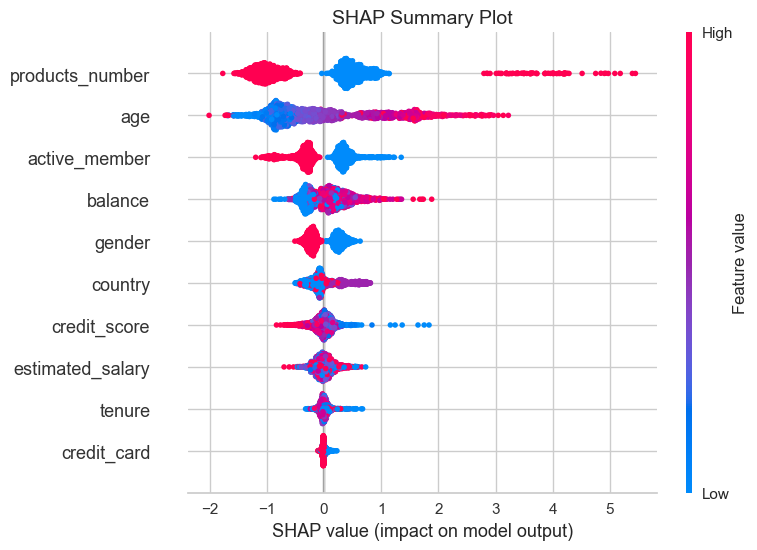

In [ ]:
# shap을 이용한 모델 분석
import shap
explainer = shap.TreeExplainer(lgbm_model) # lgbm_model 분석
shap_values = explainer.shap_values(X_valid) # x_valid에 대해  shap 계산

#shap 값 형태 정리
if isinstance(shap_values, list):
 
    shap_values_plot = shap_values[1]
elif hasattr(shap_values, "ndim") and shap_values.ndim == 3: # 3차원으로 나온 경우
  
    shap_values_plot = shap_values[:, :, 1]
else:
    shap_values_plot = shap_values # 2차원으로 잘 나온 경우


shap.summary_plot(
    shap_values_plot, #shap 값
    X_valid,  # x_valid에 대해  shap 계산 데이터
    feature_names=X.columns, # 변수 이름 리스트
    plot_type='dot', # 점 형태
    show=False # plt를 통해 보여줄 것
)

plt.title('SHAP Summary Plot', fontsize=14) # 그래프 이름
plt.show() # 출력

shap 분석
1. product_number의 경우 값이 높은 경우 이탈(=1)하는 방향과 이탈하지 않는(=0) 방향 즉 양쪽으로 분포하고 있음. -> 예측값이 일정하게 한쪽으로 작용하지 않음
2. age의 경우 값이 높을수록 이탈하는 방향으로 예측값을 증가시키는 경향 있음
3. active_member의 경우, 값이 낮은 경우가 이탈하는 방향으로, 값이 높은 경우는 이탈하지않는 쪽에 분포하는 경향이 나타나, active_member 값에 따라 예측 방향이 반대로 작용함을 확인
4. balance 변수는 값이 높은 경우가 이탈하는 방향으로 분포해 클수록 이탈에 영향을 주는 패턴
5. credit_score의 경우 낮을수록 이탈하는 방향으로 분포함
6. 반면 credit_card, tenure, estimated_salary 등은 SHAP 값의 분포가 0 근처에 집중되어 있어, 상대적으로 모델 예측에 미치는 영향이 작은 변수로 판단

인사이트 제안\
shap 분석을 통해 인사인트를 종합하면
products_number, age, active_member, balance 가 상대적으로 주요 영향을 주는 변수로 나타났다

products_number의 같은 경우 값이 높은 경우 양수 및 음수 SHAP 값에 모두 분포하는 것을 확인한 수 있고 예측방향이 일정하지 않기 때문에 products_number라는 단일 변수로 고객을 판단하기 보다는 여러 변수를 조합한 분석이 필요하다.

age는 값이 높은 경우 양의 SHAP 값 방향에 더 많이 분포하는 경향이 관찰되고,
active_member는 값에 따라 예측 방향이 shap과는 반대로 나타나는 패턴이 확인된다

이 변수들의 값에 따라 예측 방향이 달라지는 패턴을 확인할 수 있었고 
따라서 주요 변수들을 중심으로 그룹을 나누어 이탈 확률이 높은 집단을 식별하고 
대상으로 맞춤형 관리 전략 수립이 필요하며 해당 집단을 우선적으로 관리한다면 전략이 더욱 효과적일 수 있다.
또한 단일 기준이 아닌 여러 변수들을 기준으로 세분화할 필요가 있다.

In [ ]:
# Stacking
est_model_list = [
    ('lgbm', lgbm_model),
    ('cat', cat_model),
    ('xgb', xgb_model)
]

 
stack = StackingClassifier(
    estimators=est_model_list,
    final_estimator=LogisticRegression(max_iter=1000)
)
# 학습
stack.fit(X_train, y_train)

# 예측 및 F1 score 출력
stack_pred = stack.predict(X_valid) # 학습된 stacking 모델을 이용해서 x_valid에 대한 예측값
print("Stacking F1-score:", f1_score(y_valid, stack_pred)) # 최종 성능 확인

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000816 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning]